In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv(
    r"E:\lebika_training\spam.csv",
    encoding="latin1"
)


print(df.head())


print("Shape:", df.shape)


print("Columns:", df.columns.tolist())


print("\nMissing values:")
print(df.isnull().sum())


print("\nClass distribution:")
print(df.iloc[:, 0].value_counts())


print("\nData types:")
print(df.dtypes)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
Shape: (5572, 5)
Columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Missing values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Class distribution:
v1
ham     4825
spam     747
Name: count, dtype: int64

Data types:
v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


df = df.iloc[:, :2]


df.columns = ["label", "message"]


df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df = df.dropna()


X_text = df["message"]
y = df["label"].values


vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X = vectorizer.fit_transform(X_text).toarray()

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

X shape: (5572, 3000)
y shape: (5572,)
Training samples: (4457, 3000)
Testing samples: (1115, 3000)


In [ ]:

learning_rate = 0.01


epochs = 20


weights = np.zeros(X_train.shape[1])


bias = 0


misclassified = []


for epoch in range(epochs):

    mistakes = 0

    for i in range(len(X_train)):

       
        z = np.dot(X_train[i], weights) + bias

        
        if z >= 0:
            prediction = 1
        else:
            prediction = 0

        
        if prediction != y_train[i]:

           
            error = y_train[i] - prediction

            
            weights = weights + learning_rate * error * X_train[i]

            
            bias = bias + learning_rate * error

          
            mistakes = mistakes + 1

    
    misclassified.append(mistakes)

    print("Epoch:", epoch + 1,
          "Misclassified:", mistakes)

Epoch: 1 Misclassified: 301
Epoch: 2 Misclassified: 64
Epoch: 3 Misclassified: 26
Epoch: 4 Misclassified: 32
Epoch: 5 Misclassified: 34
Epoch: 6 Misclassified: 20
Epoch: 7 Misclassified: 10
Epoch: 8 Misclassified: 2
Epoch: 9 Misclassified: 2
Epoch: 10 Misclassified: 2
Epoch: 11 Misclassified: 4
Epoch: 12 Misclassified: 2
Epoch: 13 Misclassified: 2
Epoch: 14 Misclassified: 2
Epoch: 15 Misclassified: 2
Epoch: 16 Misclassified: 2
Epoch: 17 Misclassified: 2
Epoch: 18 Misclassified: 2
Epoch: 19 Misclassified: 2
Epoch: 20 Misclassified: 2


In [ ]:

p_predictions = []

for i in range(len(X_test)):

    z = np.dot(X_test[i], weights) + bias

    if z >= 0:
        prediction = 1
    else:
        prediction = 0

    p_predictions.append(prediction)


p_predictions = np.array(p_predictions)


correct = np.sum(p_predictions == y_test)

p_accuracy = correct / len(y_test)

print("Perceptron Accuracy:", p_accuracy)
print("Perceptron Accuracy %:", p_accuracy * 100)

Perceptron Accuracy: 0.979372197309417
Perceptron Accuracy %: 97.9372197309417


In [ ]:


message = input("Enter your message: ")


message_vector = vectorizer.transform([message]).toarray()


z = np.dot(message_vector[0], weights) + bias


if z >= 0:
    prediction = 1
else:
    prediction = 0


if prediction == 1:
    print("Perceptron Prediction: SPAM")
else:
    print("Perceptron Prediction: HAM")

Perceptron Prediction: SPAM


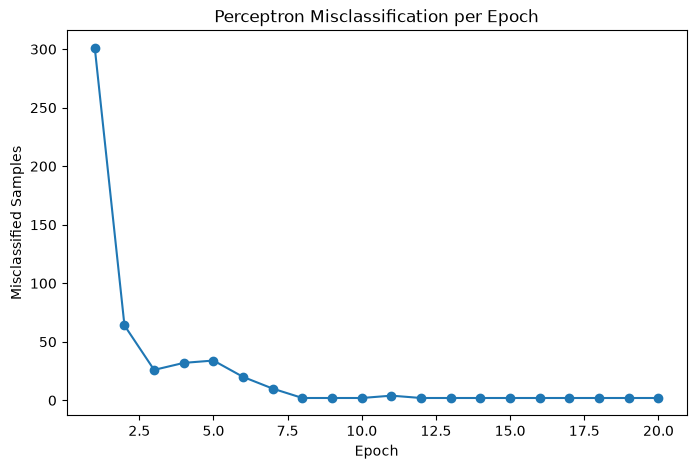

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    misclassified,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")

plt.title("Perceptron Misclassification per Epoch")

plt.show()

In [ ]:


learning_rate = 0.1

epochs = 20


l_weights = np.zeros(X_train.shape[1])


l_bias = 0


cost_history = []

In [ ]:
for epoch in range(epochs):

   
    z = np.dot(X_train, l_weights) + l_bias


    probability = 1 / (1 + np.exp(-z))

 
    error = probability - y_train

 
    dw = np.dot(X_train.T, error) / len(X_train)


    db = np.mean(error)

 
    l_weights = l_weights - learning_rate * dw

   
    l_bias = l_bias - learning_rate * db


    cost = -np.mean(
        y_train * np.log(probability + 1e-10)
        +
        (1 - y_train) *
        np.log(1 - probability + 1e-10)
    )


    cost_history.append(cost)

    print(
        "Epoch:", epoch + 1,
        "Cost:", cost
    )

Epoch: 1 Cost: 0.6931471803599452
Epoch: 2 Cost: 0.6797866155438956
Epoch: 3 Cost: 0.6670884471826231
Epoch: 4 Cost: 0.6550192231419527
Epoch: 5 Cost: 0.6435468472672086
Epoch: 6 Cost: 0.6326405893078585
Epoch: 7 Cost: 0.6222710824823028
Epoch: 8 Cost: 0.6124103106001244
Epoch: 9 Cost: 0.6030315864981182
Epoch: 10 Cost: 0.594109523378438
Epoch: 11 Cost: 0.585620000468506
Epoch: 12 Cost: 0.5775401242576546
Epoch: 13 Cost: 0.5698481864083086
Epoch: 14 Cost: 0.5625236192922031
Epoch: 15 Cost: 0.5555469499661755
Epoch: 16 Cost: 0.5488997532782284
Epoch: 17 Cost: 0.5425646046830485
Epoch: 18 Cost: 0.5365250332468144
Epoch: 19 Cost: 0.5307654752334182
Epoch: 20 Cost: 0.5252712285875094


In [ ]:


z_test = np.dot(
    X_test,
    l_weights
) + l_bias



l_probability = 1 / (
    1 + np.exp(-z_test)
)



l_predictions = np.where(
    l_probability >= 0.5,
    1,
    0
)



correct = np.sum(
    l_predictions == y_test
)

l_accuracy = correct / len(y_test)

print(
    "Logistic Regression Accuracy:",
    l_accuracy
)

print(
    "Logistic Regression Accuracy %:",
    l_accuracy * 100
)

Logistic Regression Accuracy: 0.8663677130044843
Logistic Regression Accuracy %: 86.63677130044843


In [11]:
message = input("Enter your message: ")

# Convert text to numbers
message_vector = vectorizer.transform(
    [message]
).toarray()

# -------------------------
# Perceptron
# -------------------------

p_z = np.dot(
    message_vector[0],
    weights
) + bias

if p_z >= 0:
    p_result = "SPAM"
else:
    p_result = "HAM"


# -------------------------
# Logistic Regression
# -------------------------

l_z = np.dot(
    message_vector[0],
    l_weights
) + l_bias

l_probability = 1 / (
    1 + np.exp(-l_z)
)

if l_probability >= 0.5:
    l_result = "SPAM"
else:
    l_result = "HAM"


# Display
print("\nPerceptron:", p_result)

print(
    "Logistic Regression:",
    l_result
)

print(
    "Logistic Spam Probability:",
    l_probability
)


Perceptron: SPAM
Logistic Regression: HAM
Logistic Spam Probability: 0.3585905855712346


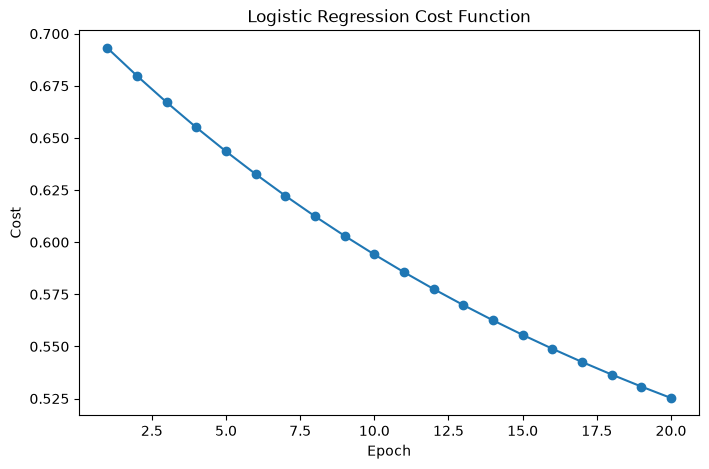

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    cost_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Cost")

plt.title(
    "Logistic Regression Cost Function"
)

plt.show()

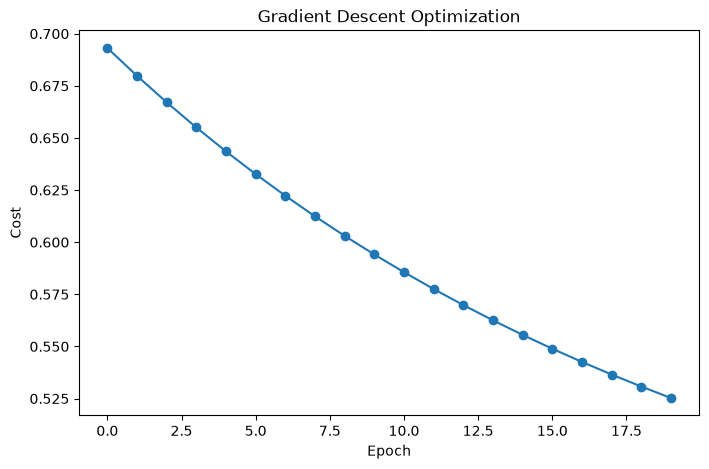

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    cost_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Cost")

plt.title(
    "Gradient Descent Optimization"
)

plt.show()

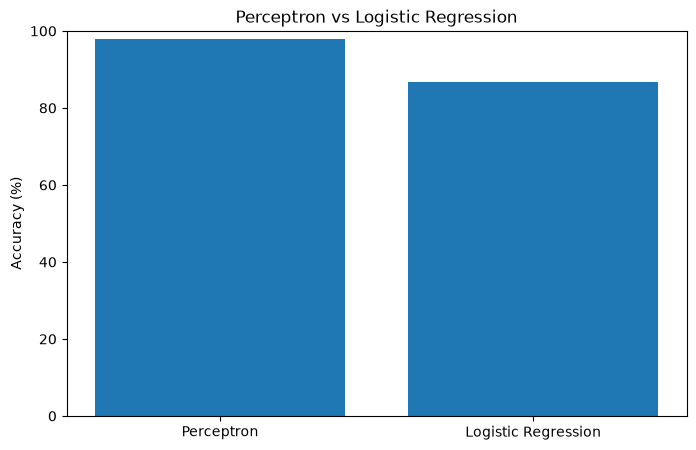

In [14]:
models = [
    "Perceptron",
    "Logistic Regression"
]

accuracy = [
    p_accuracy * 100,
    l_accuracy * 100
]

plt.figure(figsize=(8, 5))

plt.bar(
    models,
    accuracy
)

plt.ylabel("Accuracy (%)")

plt.title(
    "Perceptron vs Logistic Regression"
)

plt.ylim(0, 100)

plt.show()

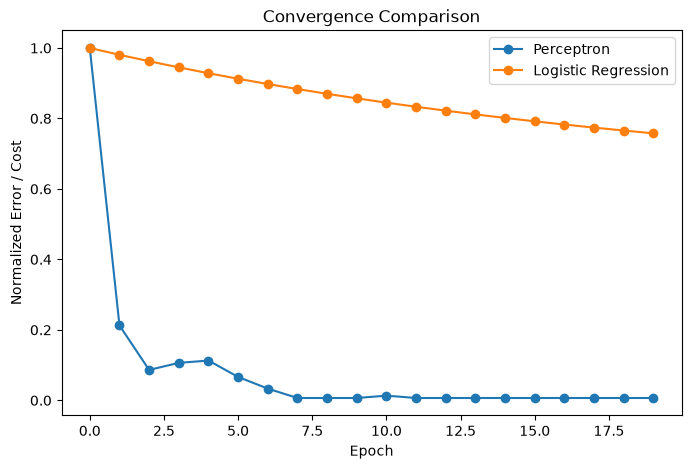

In [ ]:

p_values = np.array(
    misclassified,
    dtype=float
)

p_values = p_values / (
    p_values.max() + 1e-10
)



l_values = np.array(
    cost_history,
    dtype=float
)

l_values = l_values / (
    l_values.max() + 1e-10
)



plt.figure(figsize=(8, 5))

plt.plot(
    p_values,
    marker="o",
    label="Perceptron"
)

plt.plot(
    l_values,
    marker="o",
    label="Logistic Regression"
)

plt.xlabel("Epoch")

plt.ylabel(
    "Normalized Error / Cost"
)

plt.title(
    "Convergence Comparison"
)

plt.legend()

plt.show()